# Name : Muhammad Hassan Khalid
# 21L-5692

# Running The DBSCAN INBUILT Code

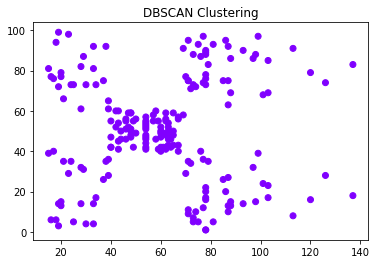

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs # import make_blobs dataset from scikit-learn
from sklearn.cluster import DBSCAN # import DBSCAN clustering algorithm from scikit-learn

# Reading the data in a csv file
data = pd.read_csv('Mall_Customers (3).csv')

x = data['Annual Income (k$)']
y = data['Spending Score (1-100)']
data = list(zip(x, y))

# Run DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5) # create an instance of DBSCAN with parameters
epsilon=0.5 
min_samples=5
dbscan.fit(data) # fit DBSCAN model to the data

# Get cluster labels
labels = dbscan.labels_ # get cluster labels from DBSCAN model

# Plot the results
plt.scatter(x, y, c=labels, cmap='rainbow') # plot the data points with different colors for different clusters
plt.title('DBSCAN Clustering') # set the title of the plot
plt.show() # show the plot

# Running The DBSCAN OWN BUILT Code

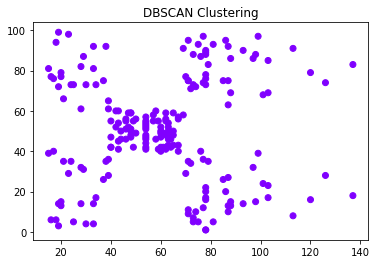

In [23]:
import numpy as np

def euclidean_distance(x, y):
    return np.sqrt(np.sum((y[1] - y[0]) ** 2))

def region_query(data, point_index, eps):
    neighbors = []
    for i in range(len(data)):
        if i != point_index:
            distance = euclidean_distance(data[i], data[point_index])
            if distance < eps:
                neighbors.append(i)
    return neighbors

def expand_cluster(data, labels, point_index, neighbors, cluster_id, eps, min_samples):
    labels[point_index] = cluster_id
    i = 0
    while i < len(neighbors):
        p = neighbors[i]
        if labels[p] == -1:
            labels[p] = cluster_id
        elif labels[p] == 0:
            labels[p] = cluster_id
            p_neighbors = region_query(data, p, eps)
            if len(p_neighbors) >= min_samples:
                neighbors = neighbors + p_neighbors
        i += 1

def dbscan(data, eps, min_samples):
    labels = np.zeros(len(data))
    cluster_id = 0
    for i in range(len(data)):
        if labels[i] != 0:
            continue
        neighbors = region_query(data, i, eps)
        if len(neighbors) < min_samples:
            labels[i] = -1
        else:
            cluster_id += 1
            expand_cluster(data, labels, i, neighbors, cluster_id, eps, min_samples)
    return labels

# Reading the data in a csv file
data = pd.read_csv('Mall_Customers (3).csv')

x = data['Annual Income (k$)']
y = data['Spending Score (1-100)']
data = list(zip(x, y))

# Run DBSCAN
epsilon=0.5 
min_samples=5
labels = dbscan(data, epsilon, min_samples)

# Plot the results
plt.scatter(x, y, c=labels, cmap='rainbow') # plot the data points with different colors for different clusters
plt.title('DBSCAN Clustering') # set the title of the plot
plt.show() # show the plot

# Running The K-MEANS INBUILT Code

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


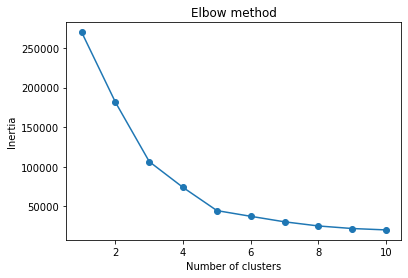

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reading the data in a csv file
data = pd.read_csv('Mall_Customers (3).csv')

from sklearn.cluster import KMeans

x = data['Annual Income (k$)']
y = data['Spending Score (1-100)']

data = list(zip(x, y))
inertias = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

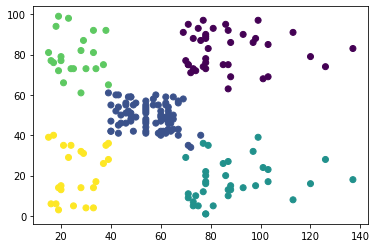

In [4]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(data)

plt.scatter(x, y, c=kmeans.labels_)

plt.show()

# Running The K-MEANS OWN BUILT Code

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
import seaborn as sns

# Reading the data in a csv file
data = pd.read_csv('Mall_Customers (3).csv')

x = data['Annual Income (k$)']
y = data['Spending Score (1-100)']

X = list(zip(x, y))

k = 5
clusters = {}
centroids = []
for i in range(k):
    clusters[i] = []

{0: [], 1: [], 2: [], 3: [], 4: [], 5: []}

for i in range(k):
    centroids[i] = X[i]

for data in X:
    euc_dist = []
    for j in range(k):
        euc_dist.append(np.linalg.norm(data - centroids[j]))
    clusters[euc_dist.index(min(euc_dist))].append(data)
    
def recalculate_clusters(X, centroids, k):
    """ Recalculates the clusters """
    # Initiate empty clusters
    clusters = {}
    # Set the range for value of k (number of centroids)
    for i in range(k):
        clusters[i] = []
    for data in X:
        euc_dist = []
        for j in range(k):
            euc_dist.append(np.linalg.norm(data - centroids[j]))
        # Append the cluster of data to the dictionary
        clusters[euc_dist.index(min(euc_dist))].append(data)
    return clusters
def recalculate_centroids(centroids, clusters, k):
    """ Recalculates the centroid position based on the plot """
    for i in range(k):
        centroids[i] = np.average(clusters[i], axis=0)
    return centroids

IndexError: list assignment index out of range

# Running The Agglomerative INBUILT Code

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


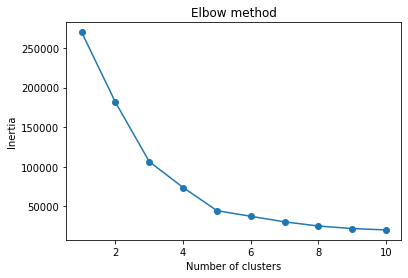

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reading the data in a csv file
data = pd.read_csv('Mall_Customers (3).csv')

from sklearn.cluster import KMeans

x = data['Annual Income (k$)']
y = data['Spending Score (1-100)']

data = list(zip(x, y))
inertias = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

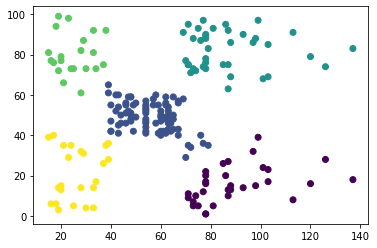

In [7]:
from sklearn.cluster import AgglomerativeClustering
import numpy as np

data = list(zip(x, y))

clustering = AgglomerativeClustering(n_clusters = 5).fit(data)

plt.scatter(x, y, c=clustering.labels_)

plt.show()

# Running The Agglomerative OWN BUILT Code

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
import seaborn as sns

# Reading the data in a csv file
data = pd.read_csv('Mall_Customers (3).csv')

import numpy as np

def euclidean_distance(x, y):
    # Compute the Euclidean distance between two points
    return np.sqrt(np.sum((x - y) ** 2))

def agglomerative_clustering(X, n_clusters):
    # Convert the input to a numpy array
    X = np.array(X)
    
    # Compute the pairwise distances between data points
    n = len(X)
    distances = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            distances[i][j] = euclidean_distance(X[i], X[j])
            distances[j][i] = distances[i][j]
            
    # Initialize the clusters
    clusters = [[i] for i in range(n)]
    
    # Merge the clusters until the desired number of clusters is reached
    while len(clusters) > n_clusters:
        # Find the indices of the two closest clusters
        min_dist = np.inf
        for i in range(len(clusters)):
            for j in range(i+1, len(clusters)):
                dist = np.min([distances[a][b] for a in clusters[i] for b in clusters[j]])
                if dist < min_dist:
                    min_dist = dist
                    merge_indices = (i, j)
        
        # Merge the two closest clusters
        clusters[merge_indices[0]] += clusters[merge_indices[1]]
        clusters.pop(merge_indices[1])
    
    # Assign labels to the data points based on the final clusters
    labels = np.zeros(n, dtype=int)
    for i, cluster in enumerate(clusters):
        for j in cluster:
            labels[j] = i
    
    return labels

In [9]:
x = data['Annual Income (k$)']
y = data['Spending Score (1-100)']

data = list(zip(x, y))

In [10]:
clustering = agglomerative_clustering(data , n_clusters = 5)

print(clustering)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 1 2 1 2 3 4]


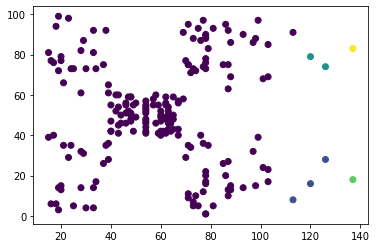

In [11]:
plt.scatter(x, y, c=clustering)

plt.show()

# END NOTES

## In My Case Agglomerative Clustering is working better than the rest as it is determining the better number of clusters and size and is nicely identifying the noise points than other cloustering techniques.